<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-TextMining/blob/main/TextMining/ex04_%EC%9C%A0%EC%82%AC%EB%8F%84_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 유사도 분석
  - 단어 또는 문서끼리 연관도, 유사도를 파악하는 기술
##### 유사도
- Similarity : 데이터 사이에 비슷한 정도를 측정하는 방법
- 텍스트마이닝에서는 두 단어 사이의 관계, 두 문서 사이의 관계를 측정할 때 사용
- 유사도의 데이터 간 거리가 가까울수록 유사도가 높다고 판단, 대표적인 거리 계산법 2가지
  1. 맨해튼 거리 공식 : 좌표 사이의 절댓값으로 거리를 구함
    - 격자 형태의 도로망에서 길을 찾는 것과 유사한 방식
  2. 유클리디언 거리 공식 : 두 점 사이의 최단 직선 거리, 피타고라스 정리를 이용하여 계산하는 방식

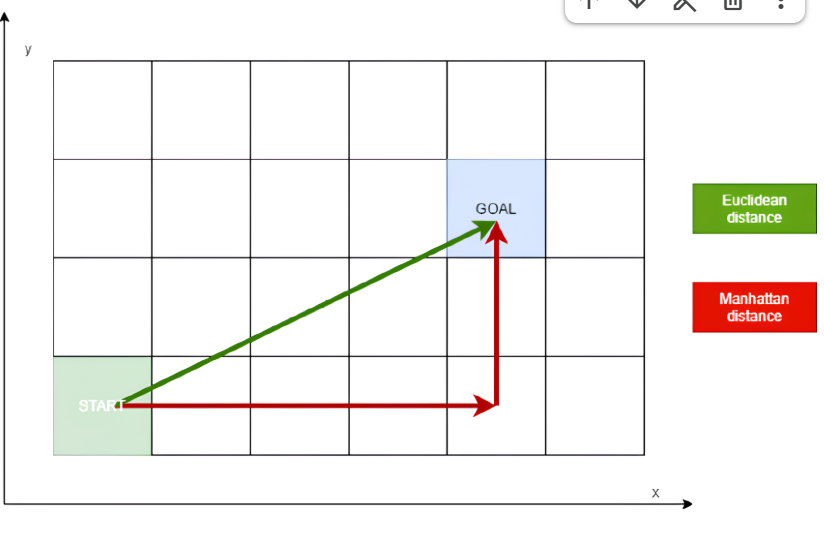

### 방향 기반의 알고리즘
- 단순 거리 기반의 유클리디언 공식을 보완
- 코사인 유사도(Cosine Similarity)
  - 두 개의 벡터 사이의 각도를 계산하여 유사도 추출
  - -1 ~ 1 사이의 값으로 도출
  - 텍스트마이닝에서 사용하는 유사도 비교 방법 (문장의 길이에 영향받는다는 단점 때문에)
  - 값보다는 방향이 중요한 추천 시스템 등에 활용

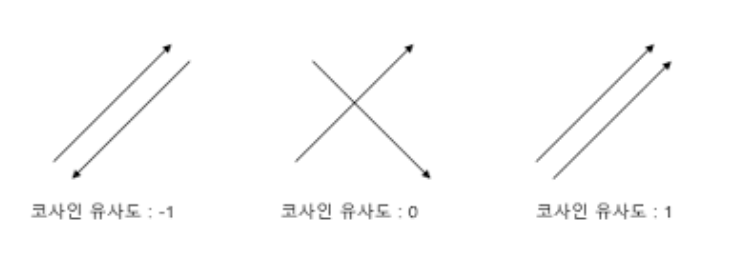

##### 코사인 유사도 해석 방법(-1 ~ 1)
- -1 : 두 벡터가 완전히 반대 방향, 정반대 개념, 반의어(ex: 좋다/나쁘다, 성공/실패)
- 0 : 두 벡터가 직각, 의미적 관련이 없음(ex: 행복/컴퓨터, 사과/정치)
- 1 : 두 벡터가 완전히 같은 방향, 의미가 유사(ex: 행복/기쁨, 좋다/만족)

### 학습목표
- 추천 시스템을 통하여 영화 추천 기능을 구현할 수 있다.

In [ ]:
# change directory(경로 수정)
%cd /content/drive/MyDrive/00 텍스트 마이닝

In [ ]:
# print work directory
!pwd

- 데이터셋 출처 : https://grouplens.org/datasets/movielens/latest/
- Grouplens 사이트에서 만든 MovieLens 데이터셋 활용

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# movies : 영화에 대한 메타정보(제목, 장르) 포함한 영화 정보데이터
movies = pd.read_csv("./data/movies.csv")
# ratings : 사용자별 영화에 대한 평점을 포함한 데이터
ratings = pd.read_csv("./data/ratings.csv")

In [ ]:
movies.head()
ratings.head()

#### Movies DataFrame

| Column  | Type   | Description                                                 |
|---------|--------|-------------------------------------------------------------|
| movieId | int64  | 영화 고유 ID. 각 영화의 식별자로, 다른 데이터셋과 연결 시 사용됨                                          |
| title   | object | 영화 제목 (출시 연도 포함). 예: "Toy Story (1995)"                                   |
| genres  | object | 영화 장르 정보. 여러 장르가 "\|" 기호로 구분되어 기록됨              |

---

#### Ratings DataFrame

| Column    | Type    | Description                                                           |
|-----------|---------|-----------------------------------------------------------------------|
| userId    | int64   | 사용자의 고유 ID. 평점을 남긴 사용자를 식별하는데 사용됨                                     |
| movieId   | int64   | 영화 고유 ID. movies 데이터셋의 movieId와 연결되어 영화 정보 참조에 활용됨              |
| rating    | float64 | 사용자가 영화에 부여한 평점. 일반적으로 0.5 간격의 값으로 영화 선호도를 표현                       |
| timestamp | int64   |평점이 기록된 시각. 유닉스 타임스탬프 형태로 저장되어, 평가 시점을 나타냄                                   |

In [ ]:
movies.info()

In [ ]:
ratings.info()

In [ ]:
# 추천에 필요 없는 timestamp 컬럼 제외 -> drop
ratings = ratings.drop("timestamp", axis=1)

### 추천 알고리즘 원리
- 취향이 비슷한 친구들에게 물어보는 방식과 유사한 방식
- 사용자가 아이템에 설정한 평점 정보나 상품 구매 이력과 같은 사용자 행동 양식을 기반으로 추천을 수행
- 우리의 영화 데이터 : 사용자의 평점을 기반으로 추천

##### 사용자 - 아이템(영화) 행렬

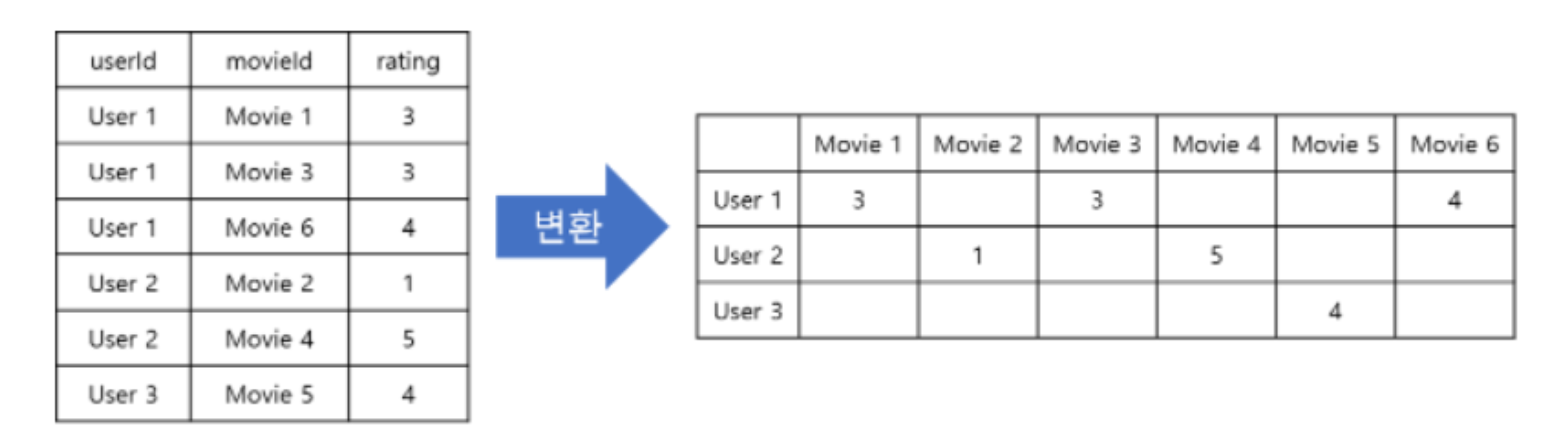

1.1 사용자-아이템 행렬 생성  
1.2 결측치 제거

In [ ]:
ratings.columns

In [ ]:
movies.columns

In [ ]:
# ratings에 영화 제목(title) 정보를 포함하기 위해서 merge를 통한 결합
rating_movie = pd.merge(ratings, movies, on = 'movieId')
rating_movie.head()

In [ ]:
# 사용자 - 아이템 행렬 -> pivot_table
ratings_matrix = rating_movie.pivot_table(index = 'userId', # 행 : 사용자 아이디
                                          columns = 'title', # 열 : 영화제목
                                          values = 'rating') # 값 : 평점

In [ ]:
ratings_matrix.head(3)

In [ ]:
ratings_matrix.shape
# 행 : 610명의 고유 사용자

In [ ]:
# Nan 값은 해당 사용자가 영화를 평가하지 않은 것, 0으로 채워주기
ratings_matrix.fillna(0, inplace=True)
ratings_matrix.head(3)

### 유사도 계산방법 2가지
1. 사용자 기반 계산법
  - 사용자 1과 비슷한 사용자 2가 이 아이템을 사용함


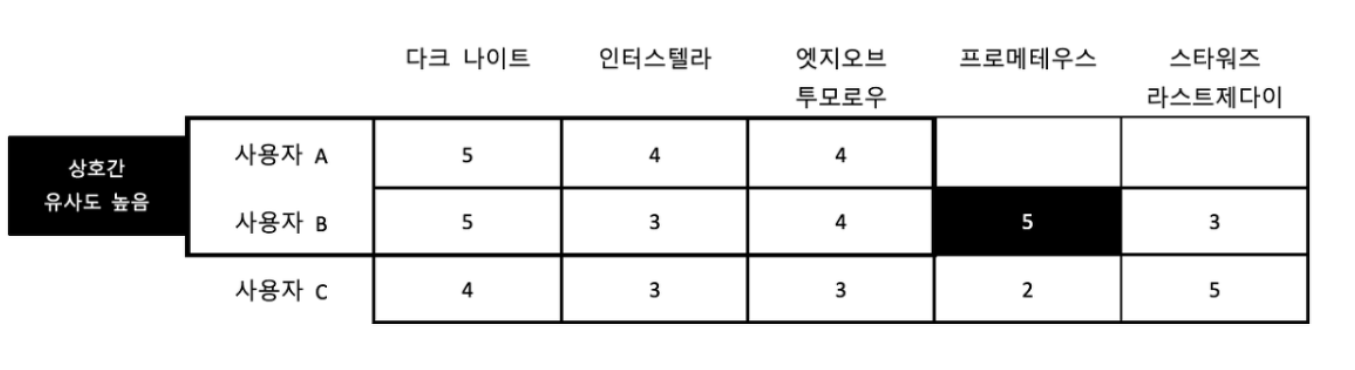

- 사용자를 기준으로 평점 대비 유사도를 확인
- 사용자 B가 높게 준 평점을 기준으로 A에게 영화를 추천
- 사용자 B의 평점을 보고 3점인 스타워즈가 아닌 5점인 프로메테우스를 추천하는 방식
- 장점 : 나와 비슷한 사람들의 취향을 반영
- 단점 : 사용자 수가 많아질수록 모든 사용자의 유사를 계산하기 어려움(확장성 문제)

2. 아이템 기반 계산법
  - 1번 영화를 본 사용자는 유사도가 높은 4번 영화도 구매함

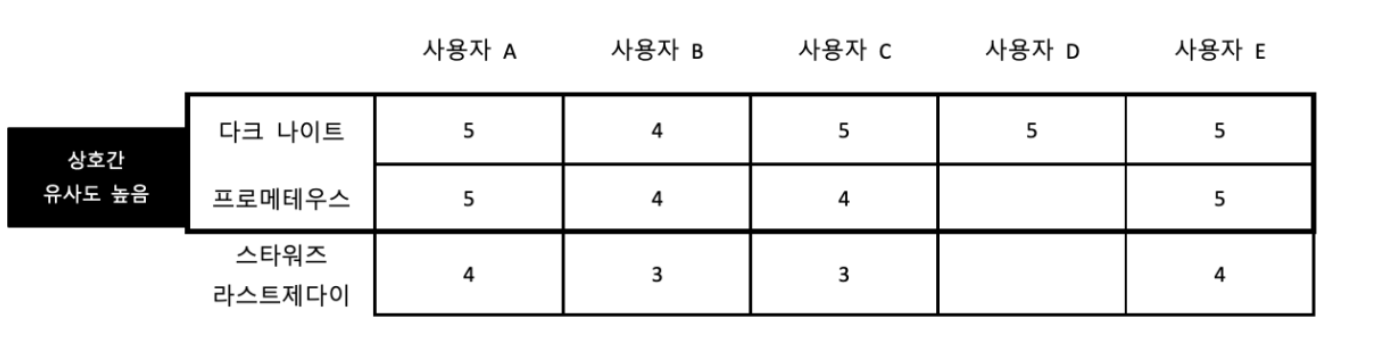

- 프로메테우스와 다크나이트의 평가결과가 유사한 패턴을 가진다면 프로메테우스를 좋아하는 사용자는 다크나이트도 좋아하겠구나 라고 추천하는 방식
- 장점 : 아이템(영화/상품) 간의 특성은 비교적 드라마틱하게 변경되지 않음, 사용자 기반보다 정확도가 높은 경우가 많음

In [ ]:
# 아이템 기반으로 유사도를 확인
# 행 : 아이템(영화데이터)
# 행렬 전치
ratings_matrix_T = ratings_matrix.T
ratings_matrix_T.head()

In [ ]:
# 영화 간 코사인 유사도 계산
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
item_sim = cosine_similarity(ratings_matrix_T, ratings_matrix_T)

In [ ]:
# 모든 영화 <-> 모든 영화 유사도를 계산
# 어떤 영화들이 비슷한가를 계산
item_sim

###### 행렬 형태
- 각 영화끼리의 유사도를 계산

|        | Movie1 | Movie2 | Movie3 |
| ------ | ------ | ------ | ------ |
| Movie1 | 1.0    | 0.23   | 0.81   |
| Movie2 | 0.23   | 1.0    | 0.12   |
| Movie3 | 0.81   | 0.12   | 1.0    |


In [ ]:
# 영화 제목을 인덱스와 컬럼에 매핑
item_sim_df = pd.DataFrame(item_sim, index = ratings_matrix.columns, columns = ratings_matrix.columns)

In [ ]:
item_sim_df.head(3)

In [ ]:
# (500) Days of Summer (2009) 와 가장 유사한 영화 확인하기~
item_sim_df['(500) Days of Summer (2009)'].sort_values(ascending=False)[1:6]

- 개인별로 아직 관람하지 않은 영화에 대해 예측평점을 계산하고 상위 영화 추천하기
  - 필터링에서 자주 사용되는 **가중평균** 방식을 활용
  - 가중평균 : 자료의 평균을 구할 때 자료값의 중요도나 영향 정도에 해당하는 가중치를 반영하여 구한 평균값
  - 아직 보지 않은 영화의 평점을 유사도로 파악하되 가중치를 주어 평균 측정

In [ ]:
# 대상 영화 선정 (미관람영화 -> 평점 0이 되는 목록 조회, 선택)
# 1번 사용자를 기준으로 미관람 영화 출력

# 1번 사용자 기준 행 추출
user1_ratings = ratings_matrix.loc[1] # loc : 라벨 기준, iloc : 인덱스 기준

# 평점이 0인 영화 정보 추출 -> 불리언 인덱싱
len(user1_ratings[user1_ratings == 0].index)

In [ ]:
# 미관람 영화 선정 ('71 (2014))
target_movie = "'71 (2014)"

In [ ]:
# 선정한 영화와 모든 영화 간 유사도 계산
item_sim_df[target_movie].sort_values(ascending = False)[1:6]

In [ ]:
# 사용자가 이미 본 영화 목록 추출하기
rated_movies = user1_ratings[user1_ratings > 0].index

# Series.nlargest(n) : 시리즈에서 값이 큰 순서대로 상위 n개의 원소를 반환
movie_sim = item_sim_df[target_movie]
top_neighbors = movie_sim[rated_movies].nlargest(5)
top_neighbors # 이미 본 영화 중, 타겟 영화(미관람)와의 유사도가 높은 5개

### Dot Product(분자계산)
- 유사도 X 평점 모두 더해 "사용자 선호의 총합 점수"를 구함
- 유사도가 높고 평점이 높을수록 더 큰 값
- 이 값을 사용자가 아직 보지 않은 영화에 대해 얼마나 좋아할지 합산한 점수
- 이후 분모로 나누어 평균화하면 예측평점
```python
# 예시 비유
- 친구 A,B,C 세 명의 추천력(유사도)과 만족도(평점)이 아래와 같다면:
  - 친구 A: 추천력 0.8, 만족도 4.0 → 기여도 3.2
  - 친구 B: 추천력 0.3, 만족도 2.0 → 기여도 0.6
  - 친구 C: 추천력 0.9, 만족도 5.0 → 기여도 4.5
- 기여도 총합 = 3.2 + 0.6 + 4.5 = 8.3
- 이 총합을 친구 추천력 총합(2.0)으로 나누면 4.15라는 평균 만족도를 얻음
```

In [ ]:
# 계산 (유사도 X 평점)
# 유사도
neighbors_item_sim = top_neighbors.values
# 평점
neighbors_item_rating = user1_ratings[top_neighbors.index].values # 이미 본 영화의 이름(top_neighbors.index)을 구하고, 그것의 평점(user1_ratings[top_neighbors.index].values)을 구함

# dot product 계산 : (유사도 X 평점).sum()
weight_sum = (neighbors_item_sim * neighbors_item_rating).sum()
weight_sum

In [ ]:
# np.dot() : 가중합 계산해주는 넘파이 함수
np.dot(top_neighbors, user1_ratings[top_neighbors.index])

In [ ]:
# 유사도의 총합으로 나누기 (음수가 존재할 수 있으므로, 절댓값을 취하기)
nor = top_neighbors.abs().sum()

In [ ]:
predict_rating = weight_sum / nor
predict_rating

- 모든 미관람 영화에 대하여 예측평점 계산

In [ ]:
from tqdm.auto import tqdm

In [ ]:
# 미관람 영화 목록
# user1_ratings[user1_ratings == 0].index
# 사용자가 이미 본 영화 목록 추출하기
rated_movies = user1_ratings[user1_ratings > 0].index
# 예측평점을 넣을 리스트 만들기
predict_rating_list = []
# 미관람 영화 선정
for i in tqdm(user1_ratings[user1_ratings == 0].index):
  movie_sim = item_sim_df[i]
  top_neighbors = movie_sim[rated_movies].nlargest(5)
  predict_rating = np.dot(top_neighbors, user1_ratings[top_neighbors.index]) / top_neighbors.abs().sum()
  predict_rating_list.append(predict_rating)

predict_rating_series = pd.Series(predict_rating_list, index=user1_ratings[user1_ratings == 0].index)
predict_rating_series.sort_values(ascending=False).head(10)

In [ ]:
predict_rating_series.sort_values(ascending=False).tail(10)

In [ ]:
# 같은 것, 강사님 코드
# 예측한 결과를 담는 딕셔너리 생성
predictions = {}
# 미관람 영화 조회하여 변수 담기
unseen_items = user1_ratings[user1_ratings == 0].index
for movie in tqdm(unseen_items):
  #1. 대상 영화와 모든 영화 간의 유사도 조회
  movie_similarity = item_sim_df[movie]
  #2. 사용자가 평점 매긴 영화 목록
  rated_movies = movie_similarity[user1_ratings > 0].index
  #3. Top-K 이웃영화 선택 (유사도 기준)
  top_neighbors = movie_similarity[rated_movies].nlargest(2)
  #4. dot product 계산 (유사도 X 평점)
  weight_sum = np.dot(top_neighbors, user1_ratings[top_neighbors.index])
  #5. 분모 계산
  nor = top_neighbors.abs().sum()
  #6. 예측평점 계산 = dot product / 분모
  pre = weight_sum / nor
  predictions[movie] = pre

In [ ]:
predictions